# LMS 학습

In [3]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]m
Get:3 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [1339 kB]
Get:4 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1487 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [43.8 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [976 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]        
Get:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB]
Get:10 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:13 http://archive.ubuntu.com/ub

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [5]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [6]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


In [7]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


In [8]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [7]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


In [9]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [10]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [10]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [11]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [12]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


In [13]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 27, 7, 39, 324, 9, 2]

In [14]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

In [15]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [16]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [18]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [19]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [20]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [21]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [23]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [24]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [26]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


In [27]:
%%time

EPOCHS = 1

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:48<00:00,  7.68it/s, loss=2.22]

Epoch 1/1, Train Loss: 3.0629
CPU times: user 47.8 s, sys: 823 ms, total: 48.6 s
Wall time: 48.8 s


In [28]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [29]:
%%time

EPOCHS = 1

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:46<00:00,  7.99it/s, loss=1.49]


Epoch 1/1, Train Loss: 1.5306, Validation Loss: 1.6291
CPU times: user 50.8 s, sys: 597 ms, total: 51.4 s
Wall time: 51.6 s


In [30]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [31]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [32]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'beb', 'est', 'mu', 'ndo', '.', '']


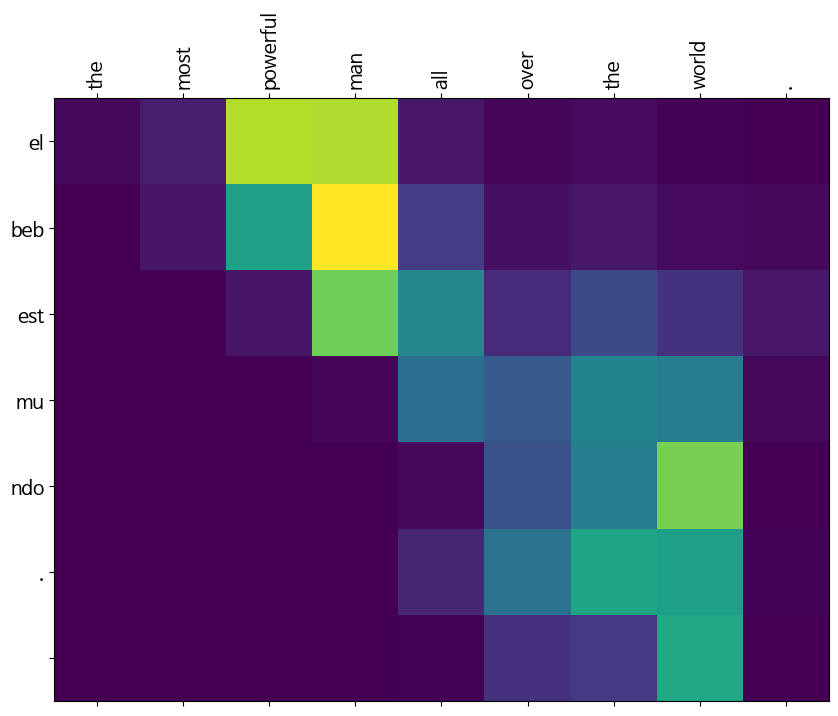

In [33]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', 'te', '?', '']


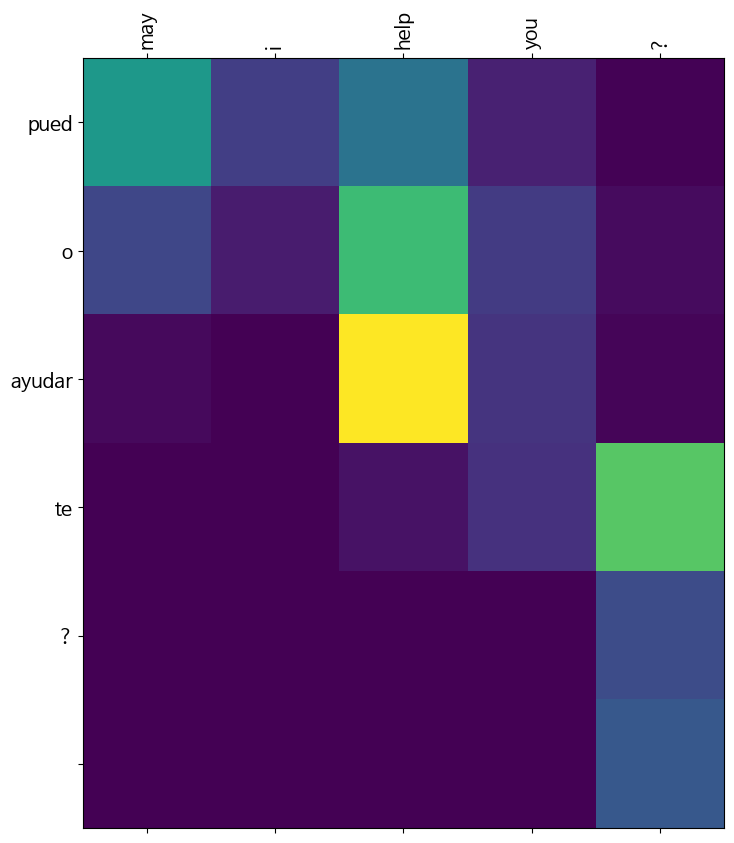

In [34]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['pued', 'o', 'tomar', 'un', 'poco', 'c', 'af', '?', '']


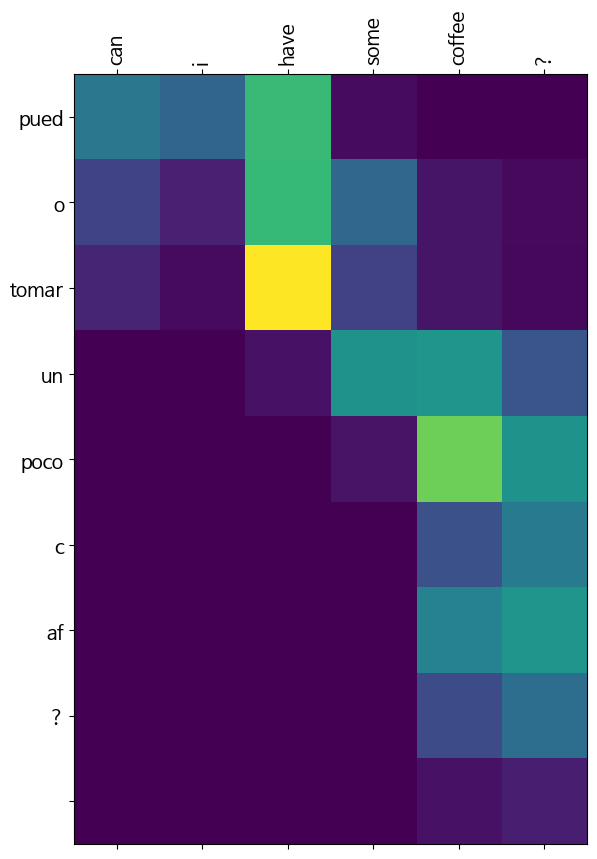

In [35]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

# 프로젝트 한국어 번역기 만들기

한국어 번역기를 만들어본다  

kiwi가 한국어 형태소 분할에 좋다고 하니 kiwi를 사용할거다  

In [36]:
!pip install kiwipiepy

In [37]:
# 프로젝트 한국어 번역기 만들기

import os
import re
import tarfile
import urllib.request
import random
import contextlib

import numpy as np
import pandas as pd
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# GPU가 사용 가능하면 cuda를 사용하고, 아니면 cpu를 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 같은 코드를 다시 실행했을 때 최대한 비슷한 결과가 나오도록 seed를 고정
SEED = 42

# Python random seed 고정
random.seed(SEED)

# numpy random seed 고정
np.random.seed(SEED)

# PyTorch random seed 고정
torch.manual_seed(SEED)

print("device:", device)
print("torch:", torch.__version__)

device: cuda
torch: 2.7.1+cu118


한국어-영어 뉴스 말뭉치를 아무거나 가져와서 학습시켜보자

In [38]:
# 데이터를 저장할 폴더를 지정
ko_project_dir = os.path.expanduser("work/s2s_translation/ko_en_project")

# 폴더가 없으면 새로 생성
os.makedirs(ko_project_dir, exist_ok=True)

# 다운로드할 압축 파일 경로를 지정
tar_path = os.path.join(ko_project_dir, "data/takorean-english-park.train.tar.gz")

# 압축 해제 후 생성되는 한국어 파일 경로
ko_path = os.path.join(ko_project_dir, "data/korean-english-park.train.ko")

# 압축 해제 후 생성되는 영어 파일 경로
en_path = os.path.join(ko_project_dir, "data/korean-english-park.train.en")

# 한국어-영어 병렬 말뭉치 다운로드 주소
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"

# 한국어 파일 또는 영어 파일이 없을 때만 다운로드와 압축 해제를 수행
if not os.path.exists(ko_path) or not os.path.exists(en_path):
    print("한국어-영어 병렬 데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)

    print("압축 해제 중...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(ko_project_dir)

print("데이터 준비 완료")
print(ko_path)
print(en_path)

데이터 준비 완료
work/s2s_translation/ko_en_project/korean-english-park.train.ko
work/s2s_translation/ko_en_project/korean-english-park.train.en


In [2]:
# 형태소 분석기 준비
# Mecab -> Okt -> Kiwi 순서로 시도
# 셋 다 없으면 설치 안내 출력
# 이것저것 하다보니 나도 헷갈린다
# 형태소 분석기 뭐가 되는지 확인해보자
morph_analyzer = None
morph_name = "사용 안 함"

try:
    from konlpy.tag import Mecab
    morph_analyzer = Mecab()
    morph_name = "Mecab"
except:
    try:
        from konlpy.tag import Okt
        morph_analyzer = Okt()
        morph_name = "Okt"
    except:
        try:
            from kiwipiepy import Kiwi
            kiwi = Kiwi()
            morph_analyzer = kiwi
            morph_name = "Kiwi"
        except:
            morph_analyzer = None
            morph_name = "형태소 분석기 없음"

print("사용 형태소 분석기:", morph_name)

if morph_analyzer is None:
    print("형태소 분석기가 없습니다.")
    print("아래 명령어 중 하나를 새 셀에서 먼저 실행하세요.")
    print("!pip install konlpy")
    print("또는")
    print("!pip install kiwipiepy")

# 한국어 문장을 형태소 단위로 분리하는 함수
def ko_morphs(sentence):
    if morph_name == "Mecab":
        return morph_analyzer.morphs(sentence)

    if morph_name == "Okt":
        return morph_analyzer.morphs(sentence)

    # Kiwi는 tokenize() 결과에서 token.form을 꺼내 형태소 리스트 생성
    if morph_name == "Kiwi":
        return [token.form for token in morph_analyzer.tokenize(sentence)]

    # 형태소 분석기가 없으면 공백 기준으로만 나누기
    return sentence.split()

# 한국어 문장 전처리 함수
def preprocess_ko(sentence):
    sentence = str(sentence).strip()

    # 구두점 앞뒤에 공백을 추가한다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 한글, 자모, 영어, 숫자, 주요 구두점만 남기고 나머지는 공백으로 바꾼다.
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)

    # 여러 개의 공백을 하나의 공백으로 줄인다.
    sentence = re.sub(r"\s+", " ", sentence).strip()

    # 한국어 형태소 분석을 수행
    sentence = " ".join(ko_morphs(sentence))

     # 형태소 분석 후 다시 공백을 정리
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# 영어 문장 전처리 함수
def preprocess_en(sentence):

    # 문자열로 변환하고 소문자로 바꾼다.
    sentence = str(sentence).lower().strip()

    # 구두점 앞뒤에 공백을 추가한다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 영어, 숫자, 주요 구두점만 남긴다.
    sentence = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", sentence)

    # 여러 개의 공백을 하나의 공백으로 줄인다.
    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence

사용 형태소 분석기: 형태소 분석기 없음
형태소 분석기가 없습니다.
아래 명령어 중 하나를 새 셀에서 먼저 실행하세요.
!pip install konlpy
또는
!pip install kiwipiepy


In [40]:
# 한국어 문장 파일을 읽는다.
with open(ko_path, "r", encoding="utf-8") as f:
    ko_lines = f.read().splitlines()

# 영어 문장 파일을 읽는다.
with open(en_path, "r", encoding="utf-8") as f:
    en_lines = f.read().splitlines()

# 한국어 문장과 영어 문장을 하나의 DataFrame으로 묶는다.
ko_df = pd.DataFrame({
    "ko": ko_lines,
    "en": en_lines
})

# 결측값을 제거
ko_df = ko_df.dropna()

# 빈 문장을 제거
ko_df = ko_df[(ko_df["ko"].str.len() > 0) & (ko_df["en"].str.len() > 0)]

# 실행 시간을 줄이기 위해 30000개만 사용
ko_df = ko_df.sample(n=min(30000, len(ko_df)), random_state=SEED).reset_index(drop=True)

# 한국어 문장에 전처리를 적용
ko_df["ko"] = ko_df["ko"].apply(preprocess_ko)

# 영어 문장에 전처리를 적용
ko_df["en"] = ko_df["en"].apply(preprocess_en)

# 전처리 후 빈 문장이 된 행을 제거
ko_df = ko_df[(ko_df["ko"].str.len() > 0) & (ko_df["en"].str.len() > 0)].reset_index(drop=True)

print("데이터 개수:", len(ko_df))
print("\n전처리 결과 확인")
display(ko_df.head())

데이터 개수: 29993

전처리 결과 확인


,ko,en
0,34 명 을 태우 ᆫ 필리핀 국내 여객기 가 추락 하 ᆫ 후 에 필리핀 해안 경비대...,the philippine coast guard and navy frogmen ar...
1,Obama Ad Will Take a Half hour of Network Prim...,british prime minister gordon brown is concern...
2,동영상 추신수 스리 런 홈런 작렬 !,korea to double african aid by . . .
3,등록 을 관리 하 는 조직 이 ᆫ 닷아시아 는 아시아 태평양 지역 을 위하 ᆫ 첫 ...,"dotasia , the organization overseeing the regi..."
4,니혼 게이자이 와 요미우리 신문 의 보도 에서 밝히 ᆫ 바 에 의하 면 일본 최대 ...,japan s biggest company and the world s number...


ㄴ 글자가 따로 논다
Kiwi 형태소 분석기의 정상 동작 이라고 한다

보기는 이상하지만 kiwi 에서는 저렇게 분리하는것이 정상이라고 하ㄴ 다

In [43]:
# 한국어 전처리 문장을 저장할 파일명
ko_corpus_path = "data/ko_corpus.txt"

# 영어 전처리 문장을 저장할 파일명
en_corpus_path = "data/en_corpus.txt"

# 한국어 문장만 txt 파일로 저장
ko_df["ko"].to_csv(ko_corpus_path, index=False, header=False, encoding="utf-8")

# 영어 문장만 txt 파일로 저장한
ko_df["en"].to_csv(en_corpus_path, index=False, header=False, encoding="utf-8")

# 단어 사전 크기를 지정
vocab_size = 4000

# 특수 토큰 id를 지정
pad_id = 0    # 패딩 토큰
bos_id = 1    # 문장 시작 토큰
eos_id = 2    # 문장 종료 토큰
unk_id = 3    # 알 수 없는 토큰


# 기존 모델이 있으면 삭제
for f in [
    "ko_encoder_spm.model",
    "ko_encoder_spm.vocab",
    "en_decoder_spm.model",
    "en_decoder_spm.vocab",
]:
    if os.path.exists(f):
        os.remove(f)


print("한국어 토크나이저 학습 중...")

# 한국어 encoder용 SentencePiece 모델을 학습
spm.SentencePieceTrainer.train(
    input=ko_corpus_path,
    model_prefix="data/ko_encoder_spm",
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id,
    hard_vocab_limit=False
)

print("영어 토크나이저 학습 중...")

# 영어 decoder용 SentencePiece 모델을 학습
spm.SentencePieceTrainer.train(
    input=en_corpus_path,
    model_prefix="data/en_decoder_spm",
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id,
    hard_vocab_limit=False
)

print("토크나이저 로딩 중...")

# 학습된 한국어 SentencePiece 모델을 불러온다.
ko_encoder_tokenizer = spm.SentencePieceProcessor()
assert ko_encoder_tokenizer.load("data/ko_encoder_spm.model")

# 학습된 영어 SentencePiece 모델을 불러온다.
en_decoder_tokenizer = spm.SentencePieceProcessor()
assert en_decoder_tokenizer.load("data/en_decoder_spm.model")

print("토크나이저 생성 완료!")
print("한국어 Encoder Vocabulary:", len(ko_encoder_tokenizer))
print("영어 Decoder Vocabulary:", len(en_decoder_tokenizer))

print("\n변수 확인")
print("ko_encoder_tokenizer:", "ko_encoder_tokenizer" in globals())
print("en_decoder_tokenizer:", "en_decoder_tokenizer" in globals())

한국어 토크나이저 학습 중...
영어 토크나이저 학습 중...


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ko_corpus.txt
  input_format: 
  model_prefix: ko_encoder_spm
  model_type: UNIGRAM
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
 

토크나이저 로딩 중...
토크나이저 생성 완료!
한국어 Encoder Vocabulary: 4000
영어 Decoder Vocabulary: 4000

변수 확인
ko_encoder_tokenizer: True
en_decoder_tokenizer: True


9) LOG(INFO) Saving model: ko_encoder_spm.model
trainer_interface.cc(701) LOG(INFO) Saving vocabs: ko_encoder_spm.vocab
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: en_corpus.txt
  input_format: 
  model_prefix: en_decoder_spm
  model_type: UNIGRAM
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_

In [44]:
# 다음 셀에서 사용할 변수가 정상적으로 생성되었는지 확인
print("ko_encoder_tokenizer" in globals())
print("en_decoder_tokenizer" in globals())

True
True


In [45]:
# 한국어 문장과 영어 문장을 모델 학습에 사용할 수 있는 tensor 형태로 바꾸는 Dataset
class KoEnTranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        # 전처리된 DataFrame을 저장
        self.data = data

        # 한국어 문장을 토큰화할 encoder tokenizer를 저장
        self.encoder_tokenizer = encoder_tokenizer

        # 영어 문장을 토큰화할 decoder tokenizer를 저장
        self.decoder_tokenizer = decoder_tokenizer

        # 문장의 최대 길이를 저장
        self.max_len = max_len

        # 특수 토큰 id를 저장
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):

        # 전체 데이터 개수를 반환
        return len(self.data)

    def __getitem__(self, idx):

        # idx번째 한국어 문장을 가져온다.
        src_text = self.data.iloc[idx]["ko"]

        # idx번째 영어 문장을 가져온다.
        trg_text = self.data.iloc[idx]["en"]

        # 한국어 문장을 정수 id 리스트로 변환
        src_ids = self.encoder_tokenizer.encode(src_text)

        # 영어 문장을 정수 id 리스트로 변환
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        # 한국어 입력 문장은 max_len보다 길면 자른다.
        src_ids = src_ids[:self.max_len]

        # decoder 입력에는 문장 시작 토큰 BOS를 붙인다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        
        # decoder 정답에는 BOS 없이 실제 정답 토큰과 EOS를 넣는다.
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 한국어 입력 길이가 max_len보다 짧으면 PAD로 채운다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))

        # decoder 입력 길이가 max_len보다 짧으면 PAD로 채운다.
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        # 모델에 넣을 수 있도록 tensor로 변환
        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

# 문장 최대 길이
MAX_LEN = 35

# 배치 사이즈
BATCH_SIZE = 64

# 데이터 학습용 80%, 검증용 20%
train_data, valid_data = train_test_split(ko_df, test_size=0.2, random_state=SEED)

# 학습 Dataset을 생성
train_dataset = KoEnTranslationDataset(
    train_data.reset_index(drop=True),
    ko_encoder_tokenizer,
    en_decoder_tokenizer,
    MAX_LEN
)

# 검증 Dataset을 생성
valid_dataset = KoEnTranslationDataset(
    valid_data.reset_index(drop=True),
    ko_encoder_tokenizer,
    en_decoder_tokenizer,
    MAX_LEN
)

# 학습 DataLoader를 생성
ko_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 검증 DataLoader를 생성
ko_valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("train:", len(train_dataset))
print("valid:", len(valid_dataset))

# 배치 shape를 확인
for src, trg_input, trg_label in ko_train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

train: 23994
valid: 5999
torch.Size([64, 35]) torch.Size([64, 35]) torch.Size([64, 35])


In [46]:
# encoder 입력 차원은 한국어 tokenizer의 vocabulary 크기
ko_input_dim = len(ko_encoder_tokenizer)

# decoder 출력 차원은 영어 tokenizer의 vocabulary 크기
en_output_dim = len(en_decoder_tokenizer)

# embedding 차원
emb_dim = 256

# GRU hidden state 차원
hid_dim = 512

# LMS 코드 Encoder 클래스를 사용
ko_encoder = Encoder(ko_input_dim, emb_dim, hid_dim).to(device)

# LMS 코드 BahdanauAttention 클래스를 사용
ko_attention = BahdanauAttention(hid_dim).to(device)

# LMS 코드 Decoder 클래스를 사용
ko_decoder = Decoder(en_output_dim, emb_dim, hid_dim, ko_attention).to(device)

# Encoder와 Decoder를 하나의 Seq2Seq Attention 모델로 묶는다.
ko_model = Seq2SeqAttention(ko_encoder, ko_decoder, device).to(device)

# Adam optimizer를 사용
ko_optimizer = optim.Adam(ko_model.parameters(), lr=1e-3)

# PAD 토큰은 loss 계산에서 제외
ko_criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("한국어 번역기 모델 생성 완료")
print(ko_model)
print("\n디코더 모델 확인")
print(ko_decoder)

한국어 번역기 모델 생성 완료
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(4000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(4000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=4000, bias=True)
  )
)

디코더 모델 확인
Decoder(
  (attention): BahdanauAttention(
    (W1): Linear(in_features=512, out_features=512, bias=True)
    (W2): Linear(in_features=512, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (embedding): Embedding(4000, 256)
  (rnn): GRU(256, 512)
  (fc_out): Linear(in_features=1024, out_features=4000, bias=True)
)


In [47]:
# 한 epoch 동안 모델을 학습시키는 함수
def ko_train_step(model, data_loader, optimizer, criterion, epoch):
    
    # 모델을 학습 모드로 설정
    model.train()

    # epoch 전체 loss를 저장할 변수
    epoch_loss = 0

    # tqdm으로 학습 진행률을 표시
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    # DataLoader에서 batch 단위로 데이터를 꺼낸다.
    for src, trg_input, trg_label in progress_bar:

        # 차원 바꿔주기
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        # 이전 batch에서 계산된 gradient를 초기화
        optimizer.zero_grad()

        # 모델에 src와 trg_input을 넣어 예측 결과를 얻는다.
        outputs, _ = model(src, trg_input)

        # CrossEntropyLoss 계산을 위해 2차원으로 펼치기
        outputs = outputs.reshape(-1, outputs.shape[-1])

        # 정답도 1차원으로 펼치기
        trg_label = trg_label.reshape(-1)

        # loss 계산
        loss = criterion(outputs, trg_label)

        # 역전파 수행
        loss.backward()

        # gradient exploding을 막기 위해 gradient clipping을 적용
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # optimizer가 모델 파라미터를 업데이트
        optimizer.step()

        # batch loss를 누적
        epoch_loss += loss.item()

        # 진행률 바에 현재 loss를 표시
        progress_bar.set_postfix(loss=loss.item())

    # epoch 평균 loss를 반환
    return epoch_loss / len(data_loader)

# 검증 데이터로 모델 loss를 계산하는 함수
def ko_eval_step(model, data_loader, criterion):

    # 모델을 평가 모드로 설정
    model.eval()

    # 전체 검증 loss를 저장할 변수
    total_loss = 0

    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:

            # 입력 문장의 차원을 모델 입력 형식에 맞게 변경
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            # 모델 예측을 수행
            outputs, _ = model(src, trg_input)

            # loss 계산을 위해 예측값을 펼치기
            outputs = outputs.reshape(-1, outputs.shape[-1])

            # loss 계산을 위해 정답을 펼치기
            trg_label = trg_label.reshape(-1)

            # loss를 계산
            loss = criterion(outputs, trg_label)
            
            # loss를 누적
            total_loss += loss.item()

    # 평균 검증 loss를 반환
    return total_loss / len(data_loader)

In [48]:
# 최대 epoch 수를 지정
EPOCHS = 10

# validation loss가 개선되지 않아도 기다릴 epoch 수
PATIENCE = 2

# epoch별 train loss를 저장할 리스트
ko_train_losses = []

# epoch별 validation loss를 저장할 리스트
ko_valid_losses = []

# 가장 낮은 validation loss를 저장
best_valid_loss = float("inf")

# validation loss가 개선되지 않은 횟수를 저장
patience_count = 0

# 가장 좋은 epoch 번호를 저장
best_epoch = 0

# 지정한 epoch 수만큼 학습을 반복
for epoch in range(EPOCHS):
    train_loss = ko_train_step(
        ko_model,
        ko_train_loader,
        ko_optimizer,
        ko_criterion,
        epoch
    )

    # 검증 loss를 계산
    valid_loss = ko_eval_step(
        ko_model,
        ko_valid_loader,
        ko_criterion
    )

    # train loss를 기록
    ko_train_losses.append(train_loss)
    ko_valid_losses.append(valid_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {valid_loss:.4f}"
    )

    # validation loss가 이전 최고 기록보다 낮으면 best model로 저장
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch + 1
        patience_count = 0

        # 현재 모델 파라미터를 파일로 저장
        torch.save(ko_model.state_dict(), "data/best_ko_translation_model.pt")
        print("best model saved")
    else:

        # validation loss가 개선되지 않으면 patience_count를 증가
        patience_count += 1
        print(f"validation loss did not improve. patience: {patience_count}/{PATIENCE}")

    # patience 횟수만큼 개선이 없으면 학습을 조기 종료
    if patience_count >= PATIENCE:
        print("early stopping")
        break

# 저장된 best model을 다시 불러오기
ko_model.load_state_dict(torch.load("data/best_ko_translation_model.pt", map_location=device))

print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Loss: {best_valid_loss:.4f}")

Epoch 1: 100%|██████████| 375/375 [01:07<00:00,  5.57it/s, loss=4.55]


Epoch 1/10 | Train Loss: 5.1727 | Validation Loss: 4.5363
best model saved


Epoch 2: 100%|██████████| 375/375 [01:07<00:00,  5.58it/s, loss=4.04]


Epoch 2/10 | Train Loss: 4.0994 | Validation Loss: 4.1160
best model saved


Epoch 3: 100%|██████████| 375/375 [01:06<00:00,  5.64it/s, loss=3.51]


...

Epoch 4/10 | Train Loss: 2.9901 | Validation Loss: 3.9108
best model saved


Epoch 5: 100%|██████████| 375/375 [01:06<00:00,  5.65it/s, loss=2.55]


Epoch 5/10 | Train Loss: 2.5379 | Validation Loss: 3.9567
validation loss did not improve. patience: 1/2


Epoch 6: 100%|██████████| 375/375 [01:06<00:00,  5.63it/s, loss=2.2] 


Epoch 6/10 | Train Loss: 2.1394 | Validation Loss: 4.0516
validation loss did not improve. patience: 2/2
early stopping
Best Epoch: 4
Best Validation Loss: 3.9108


얼리스탑으로 에포크4의 값을 저장한다  

그 이후는 과적합이라 판단하고 베스트 모델을 저장함  

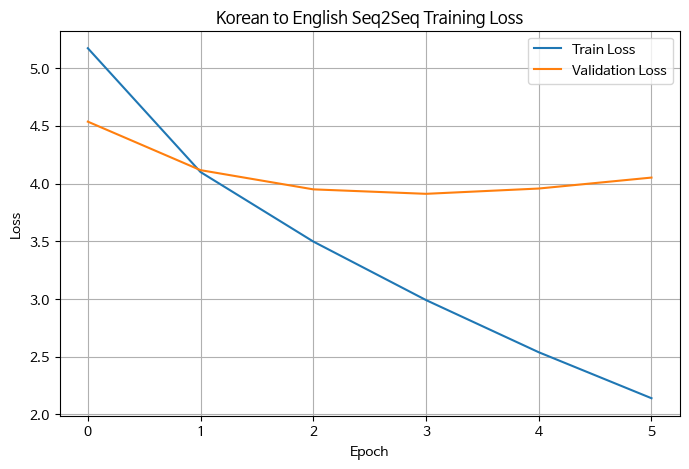

In [49]:
# 그래프 크기를 지정
plt.figure(figsize=(8, 5))

# train loss
plt.plot(ko_train_losses, label="Train Loss")

# validation loss
plt.plot(ko_valid_losses, label="Validation Loss")

# x축 epoch
plt.xlabel("Epoch")

# y축 loss
plt.ylabel("Loss")

plt.title("Korean to English Seq2Seq Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# 한국어 문장을 입력받아 영어 번역 결과를 생성하는 함수
def evaluate_ko_to_en(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=35):
    
    # 모델을 평가 모드로 설정
    model.eval()

    # 원문 확인을 위해 입력 문장을 저장
    original_sentence = sentence

    # 한국어 입력 문장에 전처리를 적용
    sentence = preprocess_ko(sentence)

    # 전처리된 한국어 문장을 정수 id로 변환
    src_ids = encoder_tokenizer.encode(sentence)

    # 너무 긴 문장은 max_len 길이로 자르기
    src_ids = src_ids[:max_len]

    # max_len보다 짧은 문장은 PAD 토큰으로 채우기
    src_ids = src_ids + [0] * (max_len - len(src_ids))

    # 모델 입력을 tensor로 변환
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():

        # trg=None으로 넣으면 모델이 직접 한 토큰씩 생성
        outputs, attentions = model(src_tensor, trg=None, max_len=max_len)

    # 각 시점에서 가장 확률이 높은 토큰 id를 선택
    pred_ids = outputs.argmax(2).squeeze(1).detach().cpu().numpy().tolist()

    # 최종 번역 토큰 id를 저장할 리스트
    result_ids = []

    # 예측된 토큰 id를 하나씩 확인
    for token_id in pred_ids:

        # EOS 토큰이 나오면 문장 생성을 종료
        if token_id == eos_id:
            break

        # PAD와 BOS는 실제 번역 결과에서 제외    
        if token_id not in [pad_id, bos_id]:
            result_ids.append(token_id)

    # 토큰 id 리스트를 실제 영어 문장으로 복원
    result = decoder_tokenizer.decode(result_ids)

    # 번역 결과, 원문, 전처리 문장, attention을 반환
    return result, original_sentence, sentence, attentions.squeeze(1).cpu().numpy()

# 번역 결과를 보기 좋게 출력하는 함수
def translate_ko_to_en(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=35):
    
    # 번역 함수를 실행
    result, original_sentence, processed_sentence, attention = evaluate_ko_to_en(
        sentence,
        model,
        encoder_tokenizer,
        decoder_tokenizer,
        max_len
    )

    print("입력 원문:", original_sentence)
    print("전처리 결과:", processed_sentence)
    print("영어 번역:", result)
    print("-" * 60)

    return result

In [51]:
# 모델이 실제로 한국어 문장을 영어로 번역하는지 확인하기 위한 예시 문장
test_sentences = [
    "나는 오늘 학교에 간다.",
    "그는 커피를 마시고 있다.",
    "이 영화는 정말 재미있다.",
    "우리는 내일 서울에서 만날 것이다.",
    "한국어 번역기 모델을 만들고 있습니다."
]

# 예시 문장을 하나씩 번역
for sentence in test_sentences:
    translate_ko_to_en(
        sentence,
        ko_model,
        ko_encoder_tokenizer,
        en_decoder_tokenizer,
        max_len=MAX_LEN
    )

입력 원문: 나는 오늘 학교에 간다.
전처리 결과: 나 는 오늘 학교 에 가 ᆫ다 .
영어 번역: i am happy to get today .
------------------------------------------------------------
입력 원문: 그는 커피를 마시고 있다.
전처리 결과: 그 는 커피 를 마시 고 있 다 .
영어 번역: he is a good drinking coffee , he says .
------------------------------------------------------------
입력 원문: 이 영화는 정말 재미있다.
전처리 결과: 이 영화 는 정말 재미있 다 .
영어 번역: the movie is too .
------------------------------------------------------------
입력 원문: 우리는 내일 서울에서 만날 것이다.
전처리 결과: 우리 는 내일 서울 에서 만나 ᆯ 것 이 다 .
영어 번역: we will not meet in our partnership , we will not meet .
------------------------------------------------------------
입력 원문: 한국어 번역기 모델을 만들고 있습니다.
전처리 결과: 한국어 번역기 모델 을 만들 고 있 습니다 .
영어 번역: koreans are commonly seen as a visa to get a cholesterol .
------------------------------------------------------------


In [53]:
print("\n[1] 테스트용 Decoder 모델 생성")

# ko_decoder가 PyTorch 모델인지 확인
print("Decoder 생성 여부 :", isinstance(ko_decoder, nn.Module))

# Decoder 클래스 이름을 출력
print(ko_decoder.__class__.__name__)
print("\n[2] Training Loss")

# epoch별 train loss를 출력
for i, loss in enumerate(ko_train_losses):
    print(f"Epoch {i+1:2d} : {loss:.4f}")

# 첫 epoch loss와 마지막 epoch loss를 비교
print("\nLoss 감소 여부 :", ko_train_losses[-1] < ko_train_losses[0])

print("\n[3] 전처리 확인")

sample_ko = "나는 오늘 학교에 간다!"
sample_en = "I Am Going To School Today!"

print("\n한국어 원문")
print(sample_ko)

print("\n한국어 전처리")
processed_ko = preprocess_ko(sample_ko)
print(processed_ko)

print("\n전처리 토큰")
print(processed_ko.split())

print("\n영어 원문")
print(sample_en)

print("\n영어 전처리")
processed_en = preprocess_en(sample_en)
print(processed_en)

print("\n영어 토큰")
print(processed_en.split())

print("\n사용 형태소 분석기 :", morph_name)

print("\n구두점 분리 확인")
print(preprocess_ko("안녕하세요! 반갑습니다."))

print("\n대소문자 처리 확인")
print(preprocess_en("I Love Deep Learning!!"))

평가기준 확인

[1] 테스트용 Decoder 모델 생성
Decoder 생성 여부 : True
Decoder

[2] Training Loss
Epoch  1 : 5.1727
Epoch  2 : 4.0994
Epoch  3 : 3.4974
Epoch  4 : 2.9901
Epoch  5 : 2.5379
Epoch  6 : 2.1394

Loss 감소 여부 : True

[3] 전처리 확인

한국어 원문
나는 오늘 학교에 간다!

한국어 전처리
나 는 오늘 학교 에 가 ᆫ다 !

전처리 토큰
['나', '는', '오늘', '학교', '에', '가', 'ᆫ다', '!']

영어 원문
I Am Going To School Today!

영어 전처리
i am going to school today !

영어 토큰
['i', 'am', 'going', 'to', 'school', 'today', '!']

사용 형태소 분석기 : Kiwi

구두점 분리 확인
안녕 하 세요 ! 반갑 습니다 .

대소문자 처리 확인
i love deep learning ! !


# 회고

시간이 더 있었으면 Kiwi 말고 다른 형태소 분석기를  써서  

더 잘 되는지 확인하고 싶은데 시간이 없어서 그러지 못했다  

왜 ㄴ 글자와 뒤의 글자가 붙어 나오는지에 대한 부분은 나중에  

더 찾아봐야 할것 같다  

kiwi는 형태소 단위의 분해를 한다  

간다 => 가 + ㄴ다 
갔다 => 가 + ㅆ다  
가겠다 => 가 + 겠다  
갑니다 => 가 + ㅂ니다  

가 = 동사
ㄴ다 = 종결어미

학습시 train과 validasion의 로스를 더 최적화 하고 싶었는데  

이것 역시 시간이 모자라서 진행하지 못했다  

코드 실행시 생기는 파일은 nlp01 폴더 하위 폴더 data를 만들고  

그 안에 정리해 두었다  
